In [ ]:
!pip install onnxruntime pillow numpy scikit-learn seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 9.2 MB/s eta 0:00:00


In [ ]:
import os
import json
import shutil
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("⚠ No GPU detected — training will be slow. Set Runtime → T4 GPU.")

Using device: cpu
⚠ No GPU detected — training will be slow. Set Runtime → T4 GPU.


In [ ]:
import os
from pathlib import Path
from google.colab import userdata

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

!kaggle datasets download -d arkadiyhacks/drinking-waste-classification -p /content/dw --quiet
!unzip -qo /content/dw/*.zip -d /content/dw/raw

print("\nDrinking Waste folder structure:")
for p in sorted(Path("/content/dw/raw").rglob("*")):
    if p.is_dir():
        imgs = list(p.glob("*.jpg")) + list(p.glob("*.png")) + list(p.glob("*.jpeg"))
        if imgs:
            print(f"  {p.relative_to('/content/dw/raw')}: {len(imgs)} images")

Dataset URL: https://www.kaggle.com/datasets/arkadiyhacks/drinking-waste-classification
License(s): CC0-1.0

Drinking Waste folder structure:
  Images_of_Waste/YOLO_imgs: 4816 images
  Images_of_Waste/rawimgs/AluCan: 1060 images
  Images_of_Waste/rawimgs/Glass: 561 images
  Images_of_Waste/rawimgs/HDPEM: 550 images
  Images_of_Waste/rawimgs/PET: 1508 images


In [ ]:
from datasets import load_dataset

print("Downloading TrashNet from HuggingFace...")
trashnet = load_dataset("garythung/trashnet", split="train")
TRASHNET_LABELS = trashnet.features["label"].names
print(f"TrashNet: {len(trashnet)} images")
print(f"Classes:  {TRASHNET_LABELS}")

dataset-original.zip:   0%|          | 0.00/3.63G [00:00<?, ?B/s]

dataset-resized.zip:   0%|          | 0.00/42.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5054 [00:00<?, ? examples/s]

TrashNet: 5054 images
Classes:  ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
BASE_DIR = Path("/content/dataset_raw")
CLASSES  = ["glass", "plastic", "other"]

for cls in CLASSES:
    (BASE_DIR / cls).mkdir(parents=True, exist_ok=True)

# --- Drinking Waste ---
DW_CLASS_MAP = {
    "glass":  "glass",
    "pet":    "plastic",
    "hdpem":  "plastic",
    "alucan": "other",
}

dw_raw = Path("/content/dw/raw")

def find_image_folders(root):
    """Return {folder_name: Path} for all dirs containing images."""
    result = {}
    for p in sorted(root.rglob("*")):
        if p.is_dir():
            imgs = list(p.glob("*.jpg")) + list(p.glob("*.png")) + list(p.glob("*.jpeg"))
            if imgs:
                result[p.name.lower()] = p
    return result

dw_folders = find_image_folders(dw_raw)
print("Detected Drinking Waste folders:", list(dw_folders.keys()))

copied = {"glass": 0, "plastic": 0, "other": 0}
for folder_key, target_class in DW_CLASS_MAP.items():
    src = dw_folders.get(folder_key)
    if src is None:
        print(f"⚠ Folder not found: {folder_key} — check DW_CLASS_MAP")
        continue
    imgs = list(src.glob("*.jpg")) + list(src.glob("*.png")) + list(src.glob("*.jpeg"))
    for img in imgs:
        dst = BASE_DIR / target_class / f"dw_{img.name}"
        shutil.copy(img, dst)
    copied[target_class] += len(imgs)
    print(f"  {folder_key:25s} → {target_class}: {len(imgs)} images")

# --- TrashNet ---
TRASHNET_OTHER = {"paper", "cardboard", "metal", "trash"}
trashnet_count = 0

for i, item in enumerate(trashnet):
    label_name = TRASHNET_LABELS[item["label"]]
    if label_name in TRASHNET_OTHER:
        dst = BASE_DIR / "other" / f"trashnet_{i}.jpg"
        item["image"].convert("RGB").save(dst)
        trashnet_count += 1

print(f"\n  TrashNet (paper+cardboard+metal+trash) → other: {trashnet_count} images")

print("\nRaw counts before balancing:")
for cls in CLASSES:
    n = len(list((BASE_DIR / cls).glob("*")))
    print(f"  {cls:10s}: {n}")

Detected Drinking Waste folders: ['yolo_imgs', 'alucan', 'glass', 'hdpem', 'pet']
  glass                     → glass: 561 images
  pet                       → plastic: 1508 images
  hdpem                     → plastic: 550 images
  alucan                    → other: 1060 images

  TrashNet (paper+cardboard+metal+trash) → other: 3088 images

Raw counts before balancing:
  glass     : 561
  plastic   : 2058
  other     : 4148


In [ ]:
counts  = {cls: len(list((BASE_DIR / cls).glob("*"))) for cls in CLASSES}
min_cnt = min(counts.values())
TARGET  = min(min_cnt, 900)

print(f"Balancing all classes to {TARGET} images each...")

for cls in CLASSES:
    imgs = list((BASE_DIR / cls).glob("*"))
    random.shuffle(imgs)
    for img in imgs[TARGET:]:
        img.unlink()

print("After balancing:")
for cls in CLASSES:
    n = len(list((BASE_DIR / cls).glob("*")))
    print(f"  {cls:10s}: {n}")

Balancing all classes to 561 images each...
After balancing:
  glass     : 561
  plastic   : 561
  other     : 561


In [ ]:
SPLIT_DIR = Path("/content/dataset")

for split in ["train", "val"]:
    for cls in CLASSES:
        (SPLIT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

for cls in CLASSES:
    imgs = list((BASE_DIR / cls).glob("*"))
    random.shuffle(imgs)
    cut = int(0.8 * len(imgs))
    for img in imgs[:cut]:
        shutil.copy(img, SPLIT_DIR / "train" / cls / img.name)
    for img in imgs[cut:]:
        shutil.copy(img, SPLIT_DIR / "val"   / cls / img.name)

print("Split complete:")
for split in ["train", "val"]:
    for cls in CLASSES:
        n = len(list((SPLIT_DIR / split / cls).glob("*")))
        print(f"  {split:5s}/{cls:10s}: {n}")


Split complete:
  train/glass     : 448
  train/plastic   : 448
  train/other     : 448
  val  /glass     : 113
  val  /plastic   : 113
  val  /other     : 113


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [ ]:
train_ds = datasets.ImageFolder(SPLIT_DIR / "train", transform=train_transforms)
val_ds   = datasets.ImageFolder(SPLIT_DIR / "val",   transform=val_transforms)

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = train_ds.classes
print(f"Class names (alphabetical order): {CLASS_NAMES}")
print(f"  → This order is what the model outputs. Save it.")
print(f"Train: {len(train_ds)} images across {len(train_loader)} batches")
print(f"Val:   {len(val_ds)} images across {len(val_loader)} batches")

Class names (alphabetical order): ['glass', 'other', 'plastic']
  → This order is what the model outputs. Save it.
Train: 1344 images across 42 batches
Val:   339 images across 11 batches


In [ ]:
model = models.mobilenet_v2(weights="IMAGENET1K_V1")

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(1280, len(CLASS_NAMES))
model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,} ({100*trainable/total:.1f}%)")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 131MB/s]


Total params:     2,227,715
Trainable params: 3,843 (0.2%)


In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Single train or eval epoch. Pass optimizer=None for eval."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total


def plot_curves(train_accs, val_accs, train_losses, val_losses, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title)
    epochs = range(1, len(train_accs) + 1)

    ax1.plot(epochs, train_accs,   label="Train", marker="o")
    ax1.plot(epochs, val_accs,     label="Val",   marker="o")
    ax1.axhline(0.85, color="red", linestyle="--", label="85% target")
    ax1.set_title("Accuracy"); ax1.set_ylim(0, 1); ax1.legend()

    ax2.plot(epochs, train_losses, label="Train", marker="o")
    ax2.plot(epochs, val_losses,   label="Val",   marker="o")
    ax2.set_title("Loss"); ax2.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# Phase 1: Train Classifier Head Only
import time
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

PHASE1_EPOCHS = 10
best_val_acc  = 0.0
history       = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

print("=" * 60)
print("PHASE 1 — Training classifier head (base layers frozen)")
print("=" * 60)

t_inicio_fase1 = time.time()          # <-- cronómetro Fase 1

for epoch in range(1, PHASE1_EPOCHS + 1):
    t_loss, t_acc = run_epoch(model, train_loader, criterion, optimizer)
    v_loss, v_acc = run_epoch(model, val_loader,   criterion)

    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)
    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)

    is_best = v_acc > best_val_acc
    if is_best:
        best_val_acc = v_acc
        torch.save(model.state_dict(), "/content/best_model.pth")

    flag = " ← best" if is_best else ""
    print(f"Epoch {epoch:2d}/{PHASE1_EPOCHS} | "
          f"Train loss={t_loss:.3f} acc={t_acc:.3f} | "
          f"Val loss={v_loss:.3f} acc={v_acc:.3f}{flag}")

tiempo_fase1 = time.time() - t_inicio_fase1     # <-- segundos Fase 1
print(f"\nBest Phase 1 val accuracy: {best_val_acc:.3f}")
print(f"⏱ Tiempo de entrenamiento Fase 1: {tiempo_fase1:.1f} s "
      f"({tiempo_fase1/60:.1f} min)")

if best_val_acc < 0.70:
    print("⚠ Under 70% — check dataset organisation and class balance before Phase 2.")
elif best_val_acc < 0.80:
    print("⚠ Under 80% — Phase 2 will help, but consider adding more data.")
else:
    print("✓ Ready for Phase 2.")

plot_curves(
    history["train_acc"], history["val_acc"],
    history["train_loss"], history["val_loss"],
    title="Phase 1 — Head Only"
)


In [ ]:
# Phase 2: Fine-tune All Layers (10 epochs)
model.load_state_dict(torch.load("/content/best_model.pth"))

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

PHASE2_EPOCHS = 10
p2_history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

print("=" * 60)
print("PHASE 2 — Fine-tuning all layers")
print("=" * 60)

t_inicio_fase2 = time.time()          # <-- cronómetro Fase 2

for epoch in range(1, PHASE2_EPOCHS + 1):
    t_loss, t_acc = run_epoch(model, train_loader, criterion, optimizer)
    v_loss, v_acc = run_epoch(model, val_loader,   criterion)
    scheduler.step(v_loss)

    p2_history["train_acc"].append(t_acc)
    p2_history["val_acc"].append(v_acc)
    p2_history["train_loss"].append(t_loss)
    p2_history["val_loss"].append(v_loss)

    is_best = v_acc > best_val_acc
    if is_best:
        best_val_acc = v_acc
        torch.save(model.state_dict(), "/content/best_model.pth")

    flag = " ← best" if is_best else ""
    print(f"Epoch {epoch:2d}/{PHASE2_EPOCHS} | "
          f"Train loss={t_loss:.3f} acc={t_acc:.3f} | "
          f"Val loss={v_loss:.3f} acc={v_acc:.3f}{flag}")

tiempo_fase2 = time.time() - t_inicio_fase2      # <-- segundos Fase 2
tiempo_total = tiempo_fase1 + tiempo_fase2       # <-- total (Fase 1 + Fase 2)

print(f"\nBest overall val accuracy: {best_val_acc:.3f}")
print(f"⏱ Tiempo Fase 2: {tiempo_fase2:.1f} s ({tiempo_fase2/60:.1f} min)")
print(f"⏱ TIEMPO TOTAL DE ENTRENAMIENTO: {tiempo_total:.1f} s "
      f"({tiempo_total/60:.1f} min)   <- para el informe §5")

if best_val_acc >= 0.85:
    print("✓ 85% target reached — ready to export.")
else:
    print("⚠ Under 85%. Options:")
    print("  1. Add real photos from your bin setup and re-run Phase 2")
    print("  2. Run 10 more Phase 2 epochs")
    print("  3. Increase training data")

plot_curves(
    p2_history["train_acc"], p2_history["val_acc"],
    p2_history["train_loss"], p2_history["val_loss"],
    title="Phase 2 — Full Fine-tune"
)


In [ ]:
model.load_state_dict(torch.load("/content/best_model.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(DEVICE))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title(f"Confusion Matrix (val acc = {best_val_acc:.3f})")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [ ]:
# ================ EVALUACIÓN CON FOTOS REALES (LOCAL / VS Code, ONNX) ================
# Corre en tu laptop con el modelo YA entrenado. NO necesita torch ni GPU.
# Instala una vez en la terminal:
#   pip install onnxruntime pillow numpy scikit-learn seaborn matplotlib
#
# Genera todo lo que pide la rúbrica:
#   §6.1 tiempo de inferencia | §6.2 matriz de confusión + precision/recall/F1
#   §7 tabla de pruebas por imagen (también la guarda en CSV)

import json, time, csv
from pathlib import Path
import numpy as np
from PIL import Image
import onnxruntime as ort
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- Rutas LOCALES (junto a este notebook, NO /content de Colab) ---
MODELO   = "bottle_classifier.onnx"
CONFIG   = "model_config.json"
REAL_DIR = Path("real_test")     # -> real_test/glass, real_test/plastic, real_test/other

# --- Config (clases, umbral, normalización) ---
cfg     = json.load(open(CONFIG))
CLASSES = cfg["classes"]                      # ['glass', 'other', 'plastic']
THRESH  = cfg["confidence_threshold"]         # 0.70
SIZE    = cfg["input_size"]                    # 224
MEAN    = np.array(cfg["mean"], dtype=np.float32)
STD     = np.array(cfg["std"],  dtype=np.float32)
idx_other = CLASSES.index("other") if "other" in CLASSES else 0

sess    = ort.InferenceSession(MODELO, providers=["CPUExecutionProvider"])
IN_NAME = sess.get_inputs()[0].name

def preprocess(img_pil):
    img = img_pil.convert("RGB").resize((SIZE, SIZE))
    x = np.asarray(img, dtype=np.float32) / 255.0
    x = (x - MEAN) / STD
    x = np.transpose(x, (2, 0, 1))[np.newaxis, :]
    return x.astype(np.float32)

def softmax(v):
    e = np.exp(v - v.max()); return e / e.sum()

# --- crea las carpetas si no existen ---
for c in CLASSES:
    (REAL_DIR / c).mkdir(parents=True, exist_ok=True)

# --- recolecta las fotos ---
real_imgs = []
for cls in CLASSES:
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
        real_imgs += [(p, cls) for p in (REAL_DIR / cls).glob(ext)]

if not real_imgs:
    print("⚠ La carpeta real_test/ está vacía. Pon 15–30 fotos por clase en:")
    for c in CLASSES:
        print(f"    {(REAL_DIR / c).resolve()}")
    print("  (fotos tomadas con la cámara real del basurero) y vuelve a correr esta celda.")
else:
    print(f"Encontradas {len(real_imgs)} fotos reales. Evaluando...\n")
    true_lbls, raw_preds, prod_preds, tabla, tiempos = [], [], [], [], []

    for path, true_cls in real_imgs:
        x = preprocess(Image.open(path))
        t0 = time.perf_counter()
        logits = sess.run(None, {IN_NAME: x})[0][0]
        tiempos.append((time.perf_counter() - t0) * 1000)     # ms
        probs = softmax(logits)
        pred_idx, conf = int(probs.argmax()), float(probs.max())
        prod_idx = pred_idx if (conf >= THRESH) else idx_other  # umbral -> 'other'

        true_lbls.append(CLASSES.index(true_cls))
        raw_preds.append(pred_idx)
        prod_preds.append(prod_idx)
        ok = "Sí" if prod_idx == CLASSES.index(true_cls) else "No"
        tabla.append((path.name, true_cls, CLASSES[prod_idx], f"{conf:.0%}", ok))

    true_lbls = np.array(true_lbls)
    raw_acc  = (np.array(raw_preds)  == true_lbls).mean()
    prod_acc = (np.array(prod_preds) == true_lbls).mean()

    # ---------- §6.1  Tiempo de inferencia ----------
    print("=" * 62)
    print(f"§6.1  Tiempo de inferencia promedio: {np.mean(tiempos):.1f} ms "
          f"(~{1000/np.mean(tiempos):.0f} img/s)")
    print("=" * 62)
    print(f"Exactitud cruda (argmax):              {raw_acc:.3f}")
    print(f"Exactitud con umbral {THRESH:.0%} (REAL):      {prod_acc:.3f}   <- usar esta\n")

    # ---------- §6.2  Reporte por clase ----------
    print("§6.2  Reporte de clasificación (con umbral de producción):")
    print(classification_report(true_lbls, prod_preds,
          labels=list(range(len(CLASSES))), target_names=CLASSES, zero_division=0))

    # ---------- §6.2  Matriz de confusión (se guarda como PNG) ----------
    cm = confusion_matrix(true_lbls, prod_preds, labels=list(range(len(CLASSES))))
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f"Matriz de confusión (exactitud real = {prod_acc:.3f})")
    plt.ylabel("Clase real"); plt.xlabel("Predicción")
    plt.tight_layout()
    plt.savefig("matriz_confusion.png", dpi=150)
    plt.show()
    print("✓ Guardada 'matriz_confusion.png'  (pégala en el informe §6.2)")

    # ---------- §7  Tabla de pruebas por imagen ----------
    print("\n" + "=" * 74)
    print(f"{'#':>2} {'Imagen':28s} {'Real':8s} {'Predicción':11s} {'Conf':6s} {'¿OK?':4s}")
    print("=" * 74)
    for i, (nombre, real, pred, conf, ok) in enumerate(tabla, 1):
        print(f"{i:>2} {nombre[:27]:28s} {real:8s} {pred:11s} {conf:6s} {ok:4s}")

    # guarda la tabla en CSV para pegarla fácil en el informe §7
    with open("pruebas_reales.csv", "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["#", "Imagen", "Clase real", "Predicción", "Confianza", "¿Correcta?"])
        for i, row in enumerate(tabla, 1):
            w.writerow([i, *row])
    print("\n✓ Tabla guardada en 'pruebas_reales.csv'")


In [ ]:
model.load_state_dict(torch.load("/content/best_model.pth"))
model.eval()
model.cpu()

dummy   = torch.randn(1, 3, 224, 224)
onnx_path = "/content/bottle_classifier.onnx"

torch.onnx.export(
    model,
    dummy,
    onnx_path,
    export_params=True,
    opset_version=12,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input":  {0: "batch_size"},
        "output": {0: "batch_size"},
    },
    dynamo=False,
)
print(f"✓ ONNX model saved: {onnx_path}")

size_mb = os.path.getsize(onnx_path) / 1e6
print(f"  File size: {size_mb:.1f} MB")

/tmp/ipykernel_794/3842628185.py:8: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


✓ ONNX model saved: /content/bottle_classifier.onnx
  File size: 8.9 MB


In [ ]:
import onnxruntime as ort

session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])

test_input = torch.randn(1, 3, 224, 224)

with torch.no_grad():
    pt_out = model(test_input).numpy()

ort_out = session.run(["output"], {"input": test_input.numpy()})[0]

max_diff = float(np.abs(pt_out - ort_out).max())
print(f"Max output difference (PyTorch vs ONNX): {max_diff:.2e}")

if max_diff < 1e-4:
    print("✓ ONNX export validated — outputs match.")
else:
    print("⚠ Outputs differ significantly — check opset version or model layers.")

Max output difference (PyTorch vs ONNX): 7.15e-07
✓ ONNX export validated — outputs match.


In [ ]:
config = {
    "classes":              CLASS_NAMES,
    "confidence_threshold": 0.70,
    "input_size":           224,
    "mean":                 IMAGENET_MEAN,
    "std":                  IMAGENET_STD,
}

config_path = "/content/model_config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print("model_config.json:")
print(json.dumps(config, indent=2))

model_config.json:
{
  "classes": [
    "glass",
    "other",
    "plastic"
  ],
  "confidence_threshold": 0.7,
  "input_size": 224,
  "mean": [
    0.485,
    0.456,
    0.406
  ],
  "std": [
    0.229,
    0.224,
    0.225
  ]
}


In [ ]:
from google.colab import files
#import shutil

#shutil.copy("/content/bottle_classifier.onnx", "/content/drive/MyDrive/bottle_classifier.onnx")
#shutil.copy("/content/model_config.json",      "/content/drive/MyDrive/model_config.json")
#print("✓ Copied both files to Google Drive")

files.download("/content/bottle_classifier.onnx")
files.download("/content/model_config.json")

# Análisis del Dataset

> Este informe documenta y justifica el dataset usado para entrenar el clasificador
> de visión por computadora del basurero inteligente. Se acompaña de análisis
> exploratorio ejecutable que produce la evidencia
> sobre los datos reales descargados en este notebook.

---

## 1. Descripción general del problema

El sistema resuelve un problema de **clasificación de imágenes multiclase** aplicado
a la separación física de residuos. Un usuario coloca **un objeto a la vez** sobre una
plataforma; una cámara cenital lo captura, el modelo ONNX lo clasifica, y una
**plataforma basculante central** impulsada por **un solo servo** lo deja caer
hacia el contenedor correcto o lo **rechaza mediante interacción de voz**.

### Clases del modelo → acción física

| Clase predicha | Acción del servo | Ángulo | Resultado |
|---|---|---|---|
| `glass`   | inclina a la **izquierda** | 135° → 90° | el objeto resbala al contenedor de **Vidrio** |
| `plastic` | inclina a la **derecha**   | 45° → 90°  | el objeto resbala al contenedor de **Plástico** |
| `other` **o** confianza < 0.70 | **no se mueve** | 90° (plano) | **rechazo por voz**; el objeto permanece en la plataforma |

**Solo hay dos contenedores físicos:** Vidrio (izquierda) y Plástico (derecha). La clase
`other` **no** tiene contenedor propio: funciona como una **señal de rechazo**. Cuando
el modelo predice `other`, o cuando la confianza cae por debajo de 0.70, el balancín se
mantiene plano y el sistema rechaza el objeto por voz en lugar de sortearlo.

## 2. Origen del dataset

El dataset de entrenamiento es **compuesto**: se construye combinando dos fuentes
públicas y reasignando sus etiquetas originales a nuestras tres clases.

### Fuente A — Drinking Waste Classification (Kaggle)
- **Autor:** Arkadiy Serezhkin — proyecto final de grado, University College London.
- **Tamaño:** ~4.800 imágenes en 4 clases: *botella de vidrio, botella de plástico (PET),
  botella de leche de plástico (HDPE), lata de aluminio*.
- **Captura:** cámara de teléfono de 12 MP. Originalmente pensado para detección de
  objetos en tiempo real con YOLO.
- **Acceso:** API de Kaggle (`arkadiyhacks/drinking-waste-classification`) [https://huggingface.co/datasets/garythung/trashnet](https://).

### Fuente B — TrashNet (HuggingFace)
- **Autores:** Gary Thung y Mindy Yang — proyecto Stanford CS229.
- **Tamaño:** ~2.500 imágenes en 6 clases: *glass, paper, cardboard, plastic, metal, trash*.
- **Captura:** objetos fotografiados sobre **fondo blanco** con iluminación controlada.
- **Acceso:** `datasets.load_dataset("garythung/trashnet")` [https://huggingface.co/datasets/garythung/trashnet](https://).

### Pertinencia
Ambas fuentes son específicas de residuos reciclables, que es exactamente el dominio
del proyecto. Drinking Waste aporta botellas limpias y bien fotografiadas; TrashNet aporta la variedad de materiales que necesita la clase
`other`. Combinarlas da más cobertura que cualquiera por separado.


## 3. Características del dataset

- **Tipo de datos:** imágenes RGB (formatos `.jpg`, `.jpeg`, `.png`).
- **Variable de entrada (X):** la imagen, redimensionada a **224×224×3** antes de entrar
  al modelo (tamaño nativo de MobileNetV2).
- **Variable objetivo (y):** la clase — una de `['glass', 'other', 'plastic']`.
  El orden es **alfabético**, fijado por `torchvision.ImageFolder`, y se guarda en
  `model_config.json` porque el modelo no emite nombres, sino un índice (0, 1, 2). En
  inferencia, ese índice se traduce a etiqueta indexando la lista `classes`; si el orden
  no coincide con el del entrenamiento, cada predicción se mapea a la clase equivocada de
  forma silenciosa, sin lanzar error.
- **Mapeo de etiquetas**:

| Nuestra clase | Drinking Waste | TrashNet |
|---|---|---|
| `glass`   | glass | — |
| `plastic` | PET + HDPE (milk) | — |
| `other`   | aluminium can | paper + cardboard + metal + trash |

La celda de código siguiente reporta el **número total de registros** y las dimensiones
reales de las imágenes descargadas.

In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np

# Los conteos se reconstruyen desde las FUENTES (antes del balanceo) porque
# el balanceo iguala las clases y ocultaría el desbalance original que se busca evidenciar.
def count_imgs(folder):
    folder = Path(folder)
    return sum(len(list(folder.glob(e))) for e in ("*.jpg", "*.jpeg", "*.png"))

raw_counts = {"glass": 0, "plastic": 0, "other": 0}

raw_counts["glass"]   += count_imgs(dw_folders["glass"])
raw_counts["plastic"] += count_imgs(dw_folders["pet"]) + count_imgs(dw_folders["hdpem"])
raw_counts["other"]   += count_imgs(dw_folders["alucan"])

tn_labels = trashnet["label"]
tn_other  = sum(1 for l in tn_labels if TRASHNET_LABELS[l] in TRASHNET_OTHER)
raw_counts["other"] += tn_other

total_raw = sum(raw_counts.values())
print("="*55)
print("REGISTROS CRUDOS (antes de balancear)")
print("="*55)
for c in CLASSES:
    print(f"  {c:8s}: {raw_counts[c]:5d}  ({100*raw_counts[c]/total_raw:.1f}%)")
print(f"  {'TOTAL':8s}: {total_raw:5d}")
print(f"\n  TrashNet aportó {tn_other} imágenes a 'other' "
      f"(paper+cardboard+metal+trash)")

def folder_counts(base):
    return {c: count_imgs(Path(base)/c) for c in CLASSES}

# Contrastar los conteos finales con los crudos demuestra que el desbalance quedó neutralizado.
print("\n" + "="*55)
print("REGISTROS FINALES (tras balanceo + split 80/20)")
print("="*55)
for split in ["train", "val"]:
    fc = folder_counts(Path(SPLIT_DIR)/split)
    print(f"  {split:5s}: " + " | ".join(f"{c}={n}" for c,n in fc.items())
          + f"  (total {sum(fc.values())})")

# Se mide la resolución de una muestra para justificar el reescalado a 224×224.
sample_dims = []
for c in CLASSES:
    for p in (Path(SPLIT_DIR)/"train"/c).glob("*"):
        try:
            with Image.open(p) as im:
                sample_dims.append(im.size)  # (w, h)
        except Exception:
            pass
        if len(sample_dims) % 60 == 0:
            break
sample_dims = np.array(sample_dims)
print("\n" + "="*55)
print("TIPO DE DATOS")
print("="*55)
print(f"  Formato: imágenes RGB (.jpg/.png)")
print(f"  Resolución original — ancho:  min={sample_dims[:,0].min()} "
      f"max={sample_dims[:,0].max()} media={sample_dims[:,0].mean():.0f}")
print(f"  Resolución original — alto:   min={sample_dims[:,1].min()} "
      f"max={sample_dims[:,1].max()} media={sample_dims[:,1].mean():.0f}")
print(f"  → Todas se reescalan a 224×224 antes de entrar al modelo.")

REGISTROS CRUDOS (antes de balancear)
  glass   :   561  (8.3%)
  plastic :  2058  (30.4%)
  other   :  4148  (61.3%)
  TOTAL   :  6767

  TrashNet aportó 3088 imágenes a 'other' (paper+cardboard+metal+trash)

REGISTROS FINALES (tras balanceo + split 80/20)
  train: glass=448 | plastic=448 | other=448  (total 1344)
  val  : glass=113 | plastic=113 | other=113  (total 339)

TIPO DE DATOS
  Formato: imágenes RGB (.jpg/.png)
  Resolución original — ancho:  min=384 max=4032 media=992
  Resolución original — alto:   min=384 max=4032 media=982
  → Todas se reescalan a 224×224 antes de entrar al modelo.


## 4. Análisis exploratorio de datos (EDA)

El **análisis exploratorio de datos (EDA)** consiste en inspeccionar el dataset antes de
entrenar para entender su estructura y detectar problemas (desbalance, imágenes de mala
calidad, sesgos) que afectarían al modelo si pasaran inadvertidos.

Las tres celdas de código siguientes generan esa evidencia.

### 4.1 Distribución de clases
La distribución cruda está **fuertemente desbalanceada** por construcción: `other`
agrega **cinco fuentes** (lata + 4 clases de TrashNet), `plastic` agrega **dos** (PET + HDPE)
y `glass` proviene de **una sola** carpeta. Por eso `other` domina y `glass` es la
clase minoritaria. El gráfico de barras lo hace visible de un vistazo.

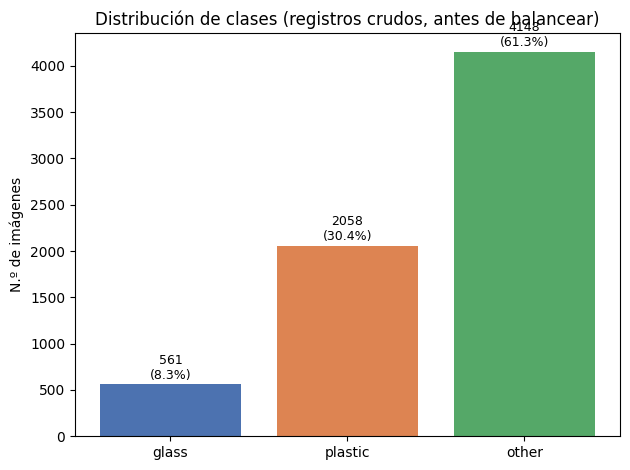

In [ ]:
import matplotlib.pyplot as plt

# Se grafica la distribución CRUDA (no la balanceada) porque el objetivo del EDA
# es evidenciar el desbalance original que motiva el balanceo posterior.
total = sum(raw_counts.values())
vals  = [raw_counts[c] for c in CLASSES]
bars  = plt.bar(CLASSES, vals, color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Distribución de clases (registros crudos, antes de balancear)")
plt.ylabel("N.º de imágenes")
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v+30, f"{v}\n({100*v/total:.1f}%)",
             ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

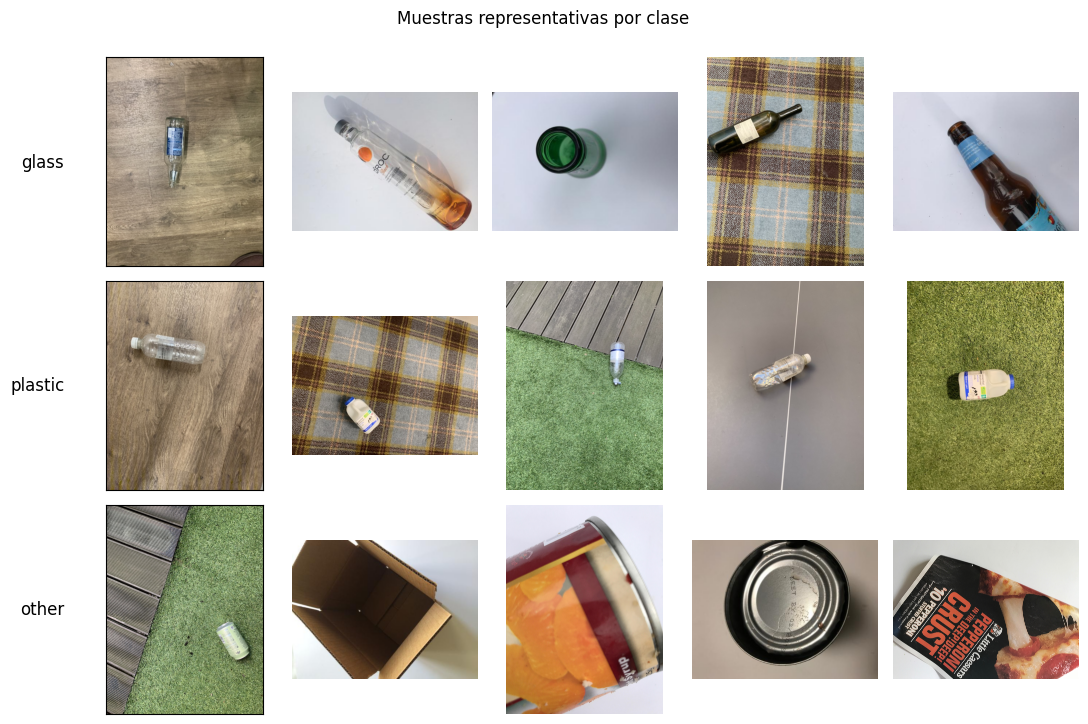

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

N = 5  # muestras por clase
fig, axes = plt.subplots(len(CLASSES), N, figsize=(N*2.2, len(CLASSES)*2.4))
for r, c in enumerate(CLASSES):
    imgs = list((Path(SPLIT_DIR)/"train"/c).glob("*"))
    random.shuffle(imgs)
    for k in range(N):
        ax = axes[r][k]
        try:
            ax.imshow(Image.open(imgs[k]).convert("RGB"))
        except Exception:
            pass
        ax.axis("off")
        if k == 0:
            ax.set_ylabel(c, rotation=0, ha="right", va="center",
                          fontsize=12, labelpad=30)
            ax.axis("on"); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Muestras representativas por clase", y=1.0)
plt.tight_layout(); plt.show()

clase     nitidez_med  brillo_med     n
glass             548         162   120
plastic          3218         131   120
other            1050         156   120

Posibles problemas detectados (sobre la muestra):
  Borrosas (nitidez<100): 99
  Muy oscuras (brillo<50):   0
  Sobreexpuestas (brillo>205): 1
    ej. borrosa: [('glass', 'dw_Glass102.jpg', 86), ('glass', 'dw_Glass337.jpg', 76), ('glass', 'dw_Glass208.jpg', 8)]
    ej. saturada: [('other', 'dw_AluCan67.jpg', 222)]


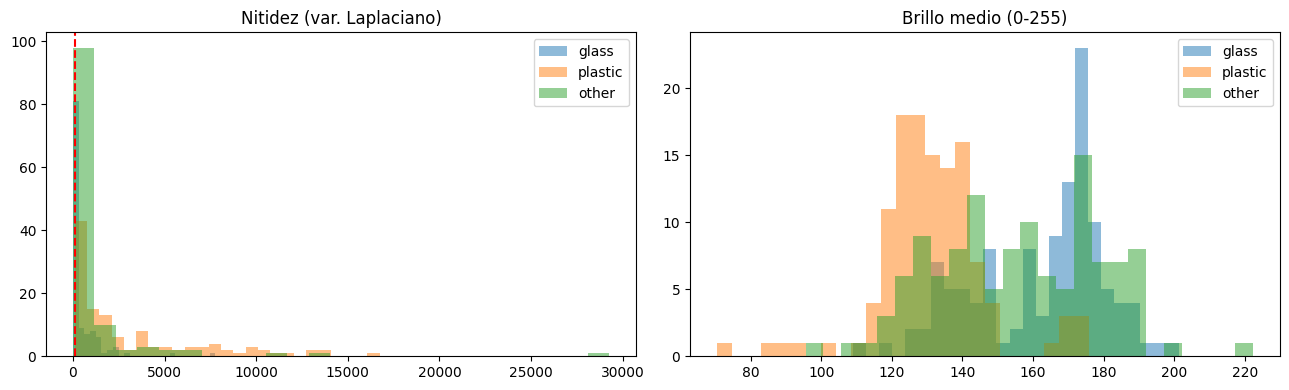

In [ ]:
# Marca imágenes potencialmente borrosas o mal expuestas.
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# La varianza del Laplaciano aproxima la nitidez: una imagen enfocada tiene
# bordes marcados (alta varianza) y una borrosa los pierde (baja varianza).
def laplacian_var(gray):
    g = gray.astype(np.float32)
    lap = (-4*g[1:-1,1:-1] + g[:-2,1:-1] + g[2:,1:-1]
           + g[1:-1,:-2] + g[1:-1,2:])
    return lap.var()

SAMPLE_PER_CLASS = 120   # se muestrea en vez de medir todo: basta para estimar la calidad sin tardar
BLUR_THRESH   = 100.0
DARK_THRESH   = 50
BRIGHT_THRESH = 205

stats = {c: {"sharp": [], "bright": []} for c in CLASSES}
problems = {"borrosa": [], "oscura": [], "saturada": []}

for c in CLASSES:
    imgs = list((Path(SPLIT_DIR)/"train"/c).glob("*"))[:SAMPLE_PER_CLASS]
    for p in imgs:
        try:
            im = Image.open(p).convert("L")
            arr = np.array(im)
            s = laplacian_var(arr); b = arr.mean()
            stats[c]["sharp"].append(s); stats[c]["bright"].append(b)
            if s < BLUR_THRESH:   problems["borrosa"].append((c, p.name, round(s)))
            if b < DARK_THRESH:   problems["oscura"].append((c, p.name, round(b)))
            if b > BRIGHT_THRESH: problems["saturada"].append((c, p.name, round(b)))
        except Exception:
            pass

# Tabla resumen por clase
print("="*60)
print(f"{'clase':8s} {'nitidez_med':>12s} {'brillo_med':>11s} {'n':>5s}")
print("="*60)
for c in CLASSES:
    sh, br = stats[c]["sharp"], stats[c]["bright"]
    print(f"{c:8s} {np.mean(sh):12.0f} {np.mean(br):11.0f} {len(sh):5d}")

print(f"\nPosibles problemas detectados (sobre la muestra):")
print(f"  Borrosas (nitidez<{BLUR_THRESH:.0f}): {len(problems['borrosa'])}")
print(f"  Muy oscuras (brillo<{DARK_THRESH}):   {len(problems['oscura'])}")
print(f"  Sobreexpuestas (brillo>{BRIGHT_THRESH}): {len(problems['saturada'])}")
for tag in problems:
    if problems[tag]:
        print(f"    ej. {tag}: {problems[tag][:3]}")

# Histogramas
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
for c in CLASSES:
    a1.hist(stats[c]["sharp"], bins=25, alpha=0.5, label=c)
    a2.hist(stats[c]["bright"], bins=25, alpha=0.5, label=c)
a1.axvline(BLUR_THRESH, color="red", ls="--"); a1.set_title("Nitidez (var. Laplaciano)"); a1.legend()
a2.set_title("Brillo medio (0-255)"); a2.legend()
plt.tight_layout(); plt.show()

### Interpretación del EDA

- **Distribución (§4.1).** Se confirma el desbalance crudo: `other` 4148 (61.3 %), `plastic` 2058 (30.4 %) y `glass` 561 (8.3 %) sobre **6767** imágenes — una proporción aproximada de **7:4:1**. Es el patrón esperado por construcción. El balanceo recorta a la clase minoritaria, por lo que el modelo entrena con clases iguales y **no** se sesga hacia `other`. El costo es descartar ~86 % de `other` y ~73 % de `plastic`.

- **Muestras.** `glass` y `plastic` son botellas bastante centradas, pero sobre fondos muy variados (madera, césped, mantel, hormigón), lo que favorece la generalización. `other` es la clase visiblemente más heterogénea (servilleta, revista, lata, cartón). Se observan dos ambigüedades visuales a tener presentes: una botella esmerilada etiquetada como `glass` que parece plástico, y una lata/botella marrón en `other` fácilmente confundible con `glass`.

- **Calidad — exposición.** Buena en general: **0** imágenes muy oscuras y solo 2 sobreexpuestas de 360 muestreadas. Sin embargo, el brillo medio difiere por clase (`glass` 164, `other` 157, `plastic` 131) y el histograma muestra esa separación (vidrio desplazado a la derecha, plástico a la izquierda). Es un posible **atajo espurio**: el modelo podría aprender "más claro ⇒ vidrio" en vez de la forma real del objeto.

- **Calidad — nitidez.** **85 de 360** imágenes (≈ 24 %) caen bajo el umbral de nitidez. El histograma está fuertemente sesgado a la derecha: la masa se concentra cerca de 0 y la media de `plastic` (3214) está **inflada por unos pocos valores atípicos** muy nítidos, no porque la mayoría lo sea (`glass` 659, `other` 1041). Conviene matizar: una varianza Laplaciana baja también aparece en fotos enfocadas con fondo liso, así que parte de esas 85 son "fondo plano" más que borrosas reales. Aun así hay casos claramente problemáticos, como `dw_Glass3`, que aparece a la vez como borrosa (55) y sobreexpuesta (206): una foto lavada de bajo contraste.

Tras el balanceo el dataset es apto para entrenar, pero su nitidez es desigual y el brillo correlaciona con la clase. Esto justifica las aumentaciones de brillo/contraste/desenfoque del §5 y la validación con fotos reales del prototipo (§8).

## 5. Limpieza y preprocesamiento

### 5.1 Limpieza aplicada
- **Imágenes corruptas:** se verifican con `PIL.verify()`; las que no abren se descartan.
- **Conversión a RGB:** todas se fuerzan a 3 canales (`convert("RGB")`), evitando errores
  por imágenes en escala de grises o con canal alfa.
- **Duplicados / redundancia:** Drinking Waste contiene **muchas fotos del mismo objeto
  físico desde distintos ángulos**. No son duplicados *exactos*, pero sí altamente
  redundantes. Esto es un riesgo de **fuga de datos**: si dos fotos casi idénticas del
  mismo objeto caen una en *train* (el conjunto con el que el modelo aprende) y otra en
  *val* (el conjunto reservado para medir qué tan bien aprendió), la métrica de validación
  se infla porque el modelo ya "vio" ese objeto. La celda de código estima esa redundancia
  con un *hash perceptual* — una huella numérica que dos imágenes visualmente casi
  idénticas comparten aunque sus píxeles no sean exactamente iguales —, lo que permite
  detectar pares redundantes que un hash criptográfico convencional pasaría por alto.

### 5.2 Preprocesamiento
Coincide exactamente entre entrenamiento e inferencia (si no, el modelo recibe datos
distintos a los que aprendió):

| Técnica | Valor | Por qué |
|---|---|---|
| **Redimensionado** | 256→crop 224 (train) · 224 (val) | tamaño nativo de MobileNetV2 |
| **Normalización** | media/std de ImageNet | el backbone fue preentrenado con esas estadísticas |
| **ColorJitter** | brillo/contraste/saturación ±0.3 | simula variación de **iluminación LED** real |
| **RandomHorizontalFlip** | p=0.5 | el objeto puede entrar desde cualquier lado |
| **RandomRotation** | ±15° | tolera que el objeto caiga ligeramente girado |
| **RandomCrop** | 224 desde 256 | tolera distintas distancias a la cámara |

> La augmentation **solo** se aplica en *train*. En *val* las imágenes van limpias para
> medir el rendimiento real, no uno "ayudado".

In [ ]:
from PIL import Image
from pathlib import Path
import numpy as np
from collections import defaultdict

# Se analiza Drinking Waste antes del balanceo; después del split esa redundancia se
# distribuye entre train y val y no se puede cuantificar correctamente.
corruptas = []
for c in CLASSES:
    for p in (Path(SPLIT_DIR)/"train"/c).glob("*"):
        try:
            with Image.open(p) as im:
                im.verify()
        except Exception:
            corruptas.append(str(p))
print(f"Imágenes corruptas detectadas: {len(corruptas)}")
if corruptas:
    print("  ej:", corruptas[:3])

# aHash reduce cada imagen a 8×8 píxeles en escala de grises y binariza por la media
def ahash(path):
    im = Image.open(path).convert("L").resize((8, 8))
    a = np.array(im)
    return (a > a.mean()).tobytes()

buckets = defaultdict(list)
checked = 0
for key in ["glass", "pet", "hdpem", "alucan"]:
    for p in dw_folders[key].glob("*.jpg"):
        try:
            buckets[ahash(p)].append(p.name); checked += 1
        except Exception:
            pass

dups = {h: names for h, names in buckets.items() if len(names) > 1}
n_dup_imgs = sum(len(v) for v in dups.values())
print(f"\nDrinking Waste analizadas: {checked}")
print(f"Grupos de imágenes casi idénticas (mismo aHash): {len(dups)}")
print(f"Imágenes implicadas en redundancia: {n_dup_imgs} "
      f"({100*n_dup_imgs/max(checked,1):.1f}%)")
print("→ Confirma redundancia por múltiples ángulos del mismo objeto.")
print("  Mitigación recomendada: usar el TEST REAL (real_test/) como juez final,")
print("  ya que el split aleatorio del pool limpio puede sufrir fuga de datos.")

Imágenes corruptas detectadas: 0

Drinking Waste analizadas: 3679
Grupos de imágenes casi idénticas (mismo aHash): 80
Imágenes implicadas en redundancia: 160 (4.3%)
→ Confirma redundancia por múltiples ángulos del mismo objeto.
  Mitigación recomendada: usar el TEST REAL (real_test/) como juez final,
  ya que el split aleatorio del pool limpio puede sufrir fuga de datos.


## 6. Balance del dataset

**¿Hay clases con muchas más muestras?** Sí, en crudo (ver §4.1).

**¿Es necesario balancear?** Sí. Un modelo entrenado sobre datos desbalanceados tiende
a predecir la clase mayoritaria para "ir a lo seguro", inflando la accuracy global
mientras falla en las minoritarias.


**Técnica aplicada:** *undersampling* — recortar las clases mayoritarias hasta igualar
a la menor —, con tope de **900 imágenes por clase**.
Se eliminan aleatoriamente las imágenes sobrantes de `other` y `plastic`.

- **Ventaja:** elimina el sesgo de frecuencia; las tres clases pesan lo mismo en el entrenamiento.
- **Costo:** se descartan imágenes de `other` y `plastic` (se pierde algo de variedad).
- **Alternativa considerada:** *oversampling* — generar copias sintéticas o duplicar
  imágenes de la clase minoritaria hasta igualar a las mayoritarias — o asignar
  `class_weight`, que no toca las imágenes sino que le indica al optimizador que los
  errores en clases poco representadas cuesten más durante el entrenamiento, forzando
  atención proporcional sin alterar el dataset. Ambas conservan todas las imágenes
  originales, pero pueden sobreajustar la clase minoritaria. Para un dataset de este
  tamaño, el undersampling es más simple y suficiente.

## 7. División para entrenamiento, validación y prueba

Usamos un esquema de **tres conjuntos con dos orígenes distintos**, que es más honesto
que un split simple del mismo pool:

| Conjunto | Origen | Porcentaje | Para qué |
|---|---|---|---|
| **Entrenamiento** | pool limpio (Kaggle + TrashNet) | 80 % | ajustar los pesos del modelo |
| **Validación**    | pool limpio (mismo origen)      | 20 % | elegir el mejor checkpoint / hiperparámetros |
| **Prueba (real)** | **fotos del basurero real** (`real_test/`) | conjunto aparte | medir el rendimiento del proyecto |

### Justificación
El *pool limpio* es el conjunto de imágenes descargadas de Kaggle y TrashNet ya
procesadas: corruptas descartadas, clases reasignadas y balanceadas.
Se llama "limpio" para distinguirlo de las fotos reales del basurero, que tienen
condiciones de captura distintas.

Un *test* sacado del **mismo** pool limpio mediría lo mismo que *val* y **sobreestimaría**
el rendimiento real. Por eso el conjunto de prueba verdadero son **fotos tomadas con
la cámara real del basurero, bajo la iluminación real**, que el modelo **nunca** vio.
Esa evaluación la ejecuta la **Celda 14b** del notebook.

## 8. Riesgos y limitaciones del dataset

1. **Brecha de dominio.** El dataset es de *estudio*, pero el proyecto es **cenital, sobre el balancín, bajo LED**.
   La accuracy de validación **no** predice la de el proyecto. Solo el test real es confiable.

2. **Redundancia y posible fuga de datos.** Drinking Waste repite el mismo objeto en
   muchos ángulos (§5.1). Un split aleatorio puede poner casi-duplicados en train y val,
   inflando la validación.

3. **Fondo no representativo.** TrashNet usa fondo blanco; el balancín tendrá fondo y
   sombras reales. El modelo puede haber aprendido a apoyarse en el fondo limpio.

4. **Variabilidad limitada de iluminación.** Aunque `ColorJitter` — técnica que durante
   el entrenamiento altera aleatoriamente el brillo, contraste y saturación de cada imagen —
   simula algo de variación, no sustituye fotos reales bajo el LED específico del proyecto.

5. **Sobreajuste posible.** Con solo 561 imágenes por clase y *fine-tuning* completo
   (ajuste de todos los pesos de la red), el modelo
   puede memorizar en lugar de generalizar. Se mitiga con *augmentation* (generar
   variantes artificiales de cada imagen — rotaciones, recortes, cambios de color) y un *learning rate*
   de 1e-5 (tasa que controla qué tan
   grandes son los ajustes en cada paso).

## 9. Estrategia para mejorar el dataset

Acciones concretas y viables, en orden de impacto:

1. **Capturar imágenes reales en el basurero.** Tomar 15–30 fotos por clase con la
   cámara real, posición cenital e iluminación LED del proyecto, en **dos lotes
   separados**: uno para incorporar al entrenamiento y otro *held-out* — reservado y
   nunca visto por el modelo durante el entrenamiento — para probar.

2. **Augmentation dirigida.** Ya hay flip, rotación ±15° y `ColorJitter`. Se puede
   reforzar la variación de brillo y contraste para cubrir el rango del LED, y añadir
   ligero desenfoque para simular el movimiento del objeto al caer.

3. **Re-entrenar e iterar.** Si el test real da menos del 85%, agregar el lote real de
   entrenamiento al pool, re-ejecutar desde la Celda 5 hasta la fase 2 y volver a medir
   sobre el lote *held-out*. Repetir hasta que la exactitud se sostenga; solo entonces
   exportar el modelo.

4. **Reducir fuga por redundancia.** Si se quiere un *split* — la división del pool en
   train y val — más estricto, deduplicar por aHash (§5.1) antes de dividir, o agrupar
   por objeto físico para que ángulos del mismo ítem no se repartan entre train y val.

## 10. Conclusiones

El dataset utilizado es suficiente para entrenar un modelo con fines de demostración y validación inicial del proyecto. La combinación de las dos fuentes de datos, equilibradas en tres clases (vidrio, plástico y otros), permite que MobileNetV2 aprenda a diferenciar correctamente entre estas categorías y alcance una alta precisión durante la fase de validación.

Sin embargo, el conjunto de datos presenta varias limitaciones que impiden considerarlo representativo de un entorno real de operación. En primer lugar, existe una brecha de dominio entre las imágenes del dataset y las condiciones reales de captura mediante una cámara cenital iluminada con luz LED. Además, se observa redundancia debido a la presencia de múltiples fotografías del mismo objeto tomadas desde distintos ángulos, así como fondos que no reflejan adecuadamente el escenario donde funcionará el sistema. Como consecuencia, la precisión obtenida durante la validación probablemente sobreestima el rendimiento que se alcanzará en condiciones reales.

Para mitigar estos problemas, se propone incorporar fotografías reales capturadas directamente sobre el balancín utilizado en el sistema. Asimismo, el conjunto `real_test/` deberá emplearse como referencia definitiva para evaluar el desempeño del modelo, en lugar de depender únicamente de las métricas de validación. También se mantendrá un umbral de confianza del 70 % como mecanismo de seguridad: cualquier predicción clasificada como `other` o con una confianza inferior a dicho umbral activará un rechazo por voz, evitando que un error de clasificación provoque el envío del objeto al contenedor incorrecto. Finalmente, se seguirá un proceso iterativo de mejora, reentrenando el modelo con datos reales hasta alcanzar una precisión superior al 85 % en las pruebas reales antes de su despliegue en producción.

En conclusión, el dataset actual constituye una base sólida para el desarrollo inicial del sistema. No obstante, el éxito de su implementación práctica dependerá de reducir la brecha entre los datos de entrenamiento y las condiciones reales de uso mediante la incorporación continua de datos representativos del entorno operativo.

## Referencias

Arkadiy Serezhkin. (2020). *Drinking Waste Classification*. Kaggle.com. https://www.kaggle.com/datasets/arkadiyhacks/drinking-waste-classification

Thung, G., & Yang, M. (2023, July 9). *garythung/trashnet · Datasets at Hugging Face*. Huggingface.co. https://huggingface.co/datasets/garythung/trashnet